In [1]:
import tensorflow as tf
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.applications.resnet50 import preprocess_input
from keras.models import Model
from keras.layers import Dense, GlobalAveragePooling2D, Input, Flatten
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

# Load the CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Normalize the data
x_train_full = x_train_full.astype('float32')
x_test = x_test.astype('float32')

In [2]:
# Preprocess the data using the preprocess_input function
x_train_full = preprocess_input(x_train_full)
x_test = preprocess_input(x_test)

# Split the training set into training and validation sets
x_train, x_valid = x_train_full[:-5000], x_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

# Convert labels to categorical
y_train = to_categorical(y_train, 10)
y_valid = to_categorical(y_valid, 10)
y_test = to_categorical(y_test, 10)

In [3]:
# Define the feature extractor using ResNet50
def feature_extractor(inputs):
    base_model = tf.keras.applications.ResNet50(input_shape=(32, 32, 3), include_top=False, weights='imagenet')
    for layer in base_model.layers:
        layer.trainable = False
    return base_model(inputs)

In [4]:
# Define the classifier
def classifier(inputs):
    x = GlobalAveragePooling2D()(inputs)
    x = Flatten()(x)
    x = Dense(1024, activation="relu")(x)
    x = Dense(512, activation="relu")(x)
    x = Dense(10, activation="softmax", name="classification")(x)
    return x

In [5]:
# Define the final model
def final_model(inputs):
    resnet_feature_extractor = feature_extractor(inputs)
    classification_output = classifier(resnet_feature_extractor)
    return classification_output

In [6]:
def define_compile_model():
    inputs = Input(shape=(32, 32, 3))
    classification_output = final_model(inputs) 
    model = Model(inputs=inputs, outputs=classification_output)
    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [7]:
# Create the model
model = define_compile_model()

# Print the model summary
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 resnet50 (Functional)       (None, 1, 1, 2048)        23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 1024)              2098176   
                                                                 
 dense_1 (Dense)             (None, 512)               524800    
                                                             

In [8]:
# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
history = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_valid, y_valid), callbacks=[early_stopping])

Epoch 1/20
1407/1407 [==============================] - 455s 319ms/step - loss: 1.1670 - accuracy: 0.6031 - val_loss: 1.0321 - val_accuracy: 0.6310
Epoch 2/20
1407/1407 [==============================] - 422s 300ms/step - loss: 0.9165 - accuracy: 0.6784 - val_loss: 0.9976 - val_accuracy: 0.6528
Epoch 3/20
1407/1407 [==============================] - 4790s 3s/step - loss: 0.7992 - accuracy: 0.7169 - val_loss: 0.9831 - val_accuracy: 0.6722
Epoch 4/20
1407/1407 [==============================] - 194s 138ms/step - loss: 0.6921 - accuracy: 0.7557 - val_loss: 0.9971 - val_accuracy: 0.6724
Epoch 5/20
1407/1407 [==============================] - 184s 131ms/step - loss: 0.5775 - accuracy: 0.7916 - val_loss: 1.1220 - val_accuracy: 0.6630
Epoch 6/20
1407/1407 [==============================] - 186s 132ms/step - loss: 0.4743 - accuracy: 0.8304 - val_loss: 1.1999 - val_accuracy: 0.6746


In [9]:
# Unfreeze the top 10 layers of the base model
for layer in model.layers[-10:]:
    layer.trainable = True

# Recompile the model with a lower learning rate
model.compile(optimizer=Adam(learning_rate=1e-5), 
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model again with unfrozen layers
history_finetune = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_valid, y_valid), callbacks=[early_stopping])

Epoch 1/10
1407/1407 [==============================] - 1649s 1s/step - loss: 1.4230 - accuracy: 0.5028 - val_loss: 1.1554 - val_accuracy: 0.6108
Epoch 2/10
1407/1407 [==============================] - 1641s 1s/step - loss: 1.0395 - accuracy: 0.6374 - val_loss: 0.9849 - val_accuracy: 0.6638
Epoch 3/10
1407/1407 [==============================] - 1634s 1s/step - loss: 0.8696 - accuracy: 0.6959 - val_loss: 0.8867 - val_accuracy: 0.7070
Epoch 4/10
1407/1407 [==============================] - 2606s 2s/step - loss: 0.7657 - accuracy: 0.7309 - val_loss: 0.8304 - val_accuracy: 0.7224
Epoch 5/10
1407/1407 [==============================] - 3247s 2s/step - loss: 0.6698 - accuracy: 0.7633 - val_loss: 0.7942 - val_accuracy: 0.7392
Epoch 6/10
1407/1407 [==============================] - 1645s 1s/step - loss: 0.5956 - accuracy: 0.7892 - val_loss: 0.7681 - val_accuracy: 0.7482
Epoch 7/10
1407/1407 [==============================] - 1637s 1s/step - loss: 0.5279 - accuracy: 0.8136 - val_loss: 0.7541 -

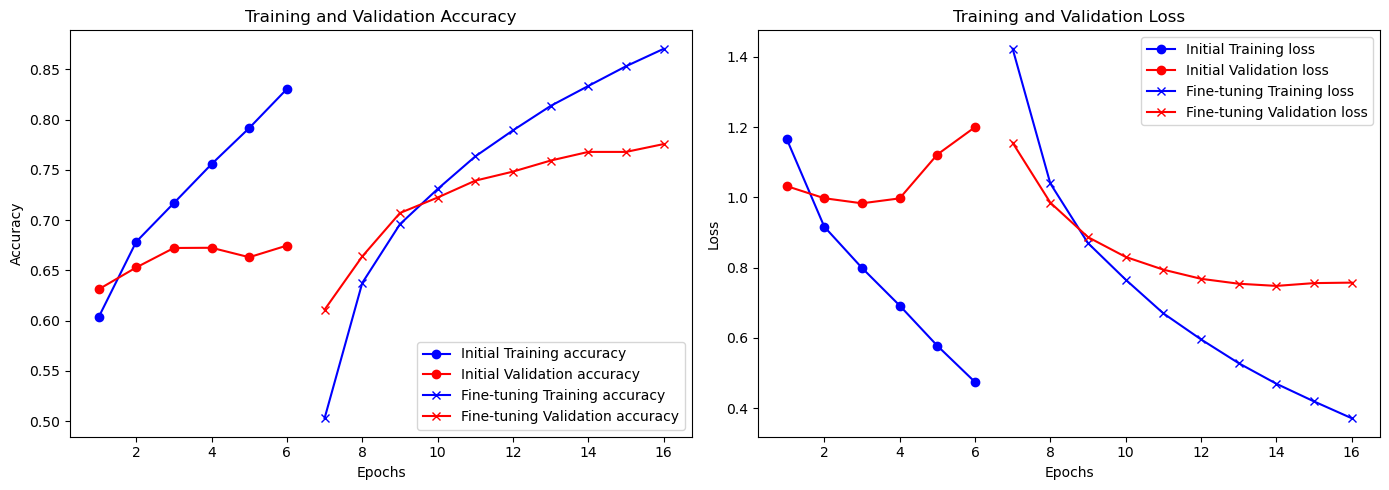

In [13]:
import matplotlib.pyplot as plt

# Extract history data
initial_history = history.history
fine_tune_history = history_finetune.history

# Initial phase data
initial_accuracy = initial_history['accuracy']
initial_val_accuracy = initial_history['val_accuracy']
initial_loss = initial_history['loss']
initial_val_loss = initial_history['val_loss']

# Fine-tuning phase data
fine_tune_accuracy = fine_tune_history['accuracy']
fine_tune_val_accuracy = fine_tune_history['val_accuracy']
fine_tune_loss = fine_tune_history['loss']
fine_tune_val_loss = fine_tune_history['val_loss']

# Epochs
initial_epochs = range(1, len(initial_accuracy) + 1)
fine_tune_epochs = range(len(initial_accuracy) + 1, len(initial_accuracy) + len(fine_tune_accuracy) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(initial_epochs, initial_accuracy, 'bo-', label='Initial Training accuracy')
plt.plot(initial_epochs, initial_val_accuracy, 'ro-', label='Initial Validation accuracy')
plt.plot(fine_tune_epochs, fine_tune_accuracy, 'bx-', label='Fine-tuning Training accuracy')
plt.plot(fine_tune_epochs, fine_tune_val_accuracy, 'rx-', label='Fine-tuning Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(initial_epochs, initial_loss, 'bo-', label='Initial Training loss')
plt.plot(initial_epochs, initial_val_loss, 'ro-', label='Initial Validation loss')
plt.plot(fine_tune_epochs, fine_tune_loss, 'bx-', label='Fine-tuning Training loss')
plt.plot(fine_tune_epochs, fine_tune_val_loss, 'rx-', label='Fine-tuning Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [15]:
import numpy as np

# Generate predictions on the test data
predictions = model.predict(x_test)

# Convert predicted probabilities to class labels
predicted_classes = np.argmax(predictions, axis=1)


313/313 [==============================] - 28s 91ms/step


In [16]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)

print(f'Test accuracy: {test_accuracy * 100:.2f}%')
print(f'Test loss: {test_loss:.4f}')


313/313 - 28s - loss: 0.8140 - accuracy: 0.7569 - 28s/epoch - 88ms/step
Test accuracy: 75.69%
Test loss: 0.8140
